# Task 7 - Customer Segmentation Using Unsupervised Learning

### Objective:

Cluster customers based on spending habits and propose marketing strategies tailored to each
segment.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Load CSV File

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Cleaning

### Rename Columns

In [3]:
df.columns = ['CustomerID', 'Genre', 'Age', 'Annual_Income', 'Spending_Score']
df.head()

,CustomerID,Genre,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Exploratory Data Analysis (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Genre           200 non-null    object
 2   Age             200 non-null    int64 
 3   Annual_Income   200 non-null    int64 
 4   Spending_Score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual_Income,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID        0
Genre             0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

### Gender Distribution

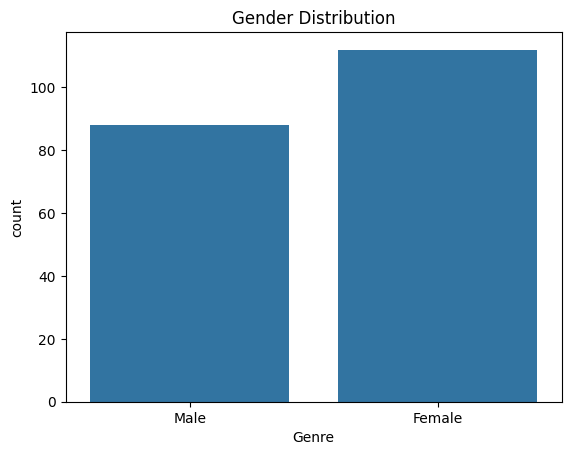

In [7]:
sns.countplot(x='Genre', data=df)
plt.title("Gender Distribution")
plt.show()

### Age vs Spending Score

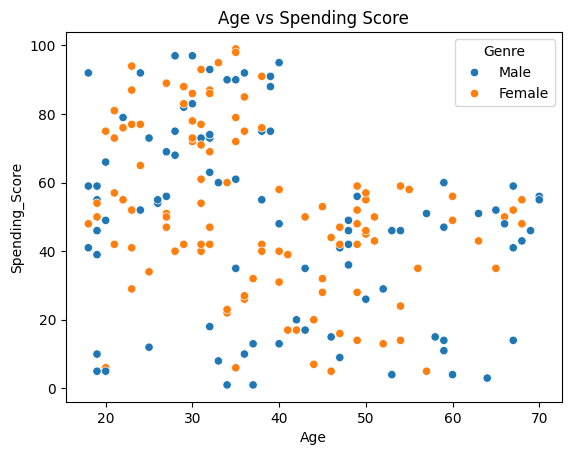

In [8]:
sns.scatterplot(x='Age', y='Spending_Score', hue='Genre', data=df)
plt.title("Age vs Spending Score")
plt.show()

### Income vs Spending Score

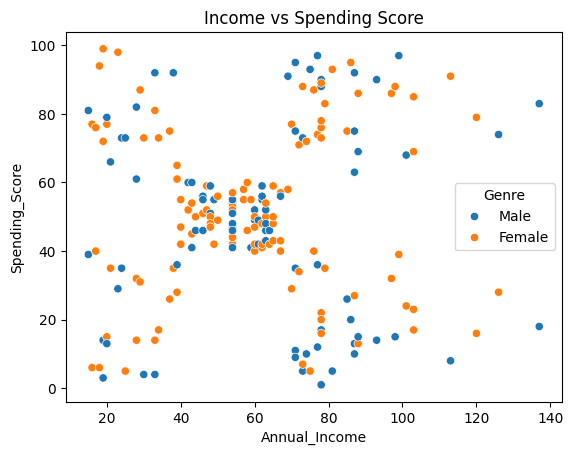

In [9]:
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Genre', data=df)
plt.title("Income vs Spending Score")
plt.show()

### Feature Selection

In [10]:
X = df[['Annual_Income', 'Spending_Score']]

### Feature Scaling

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Elbow Method (Best K)

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", l

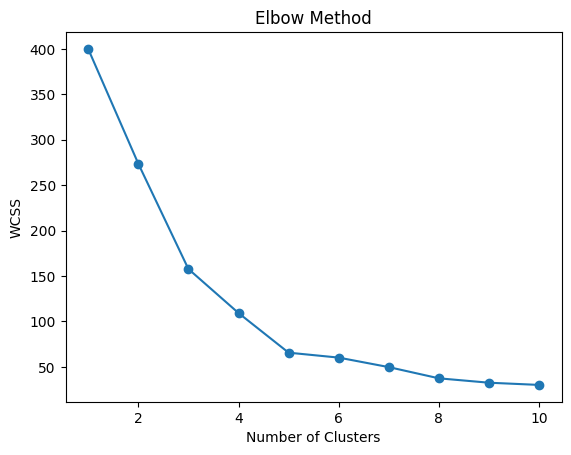

In [12]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Apply K-Means

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Genre,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### Cluster Visualization

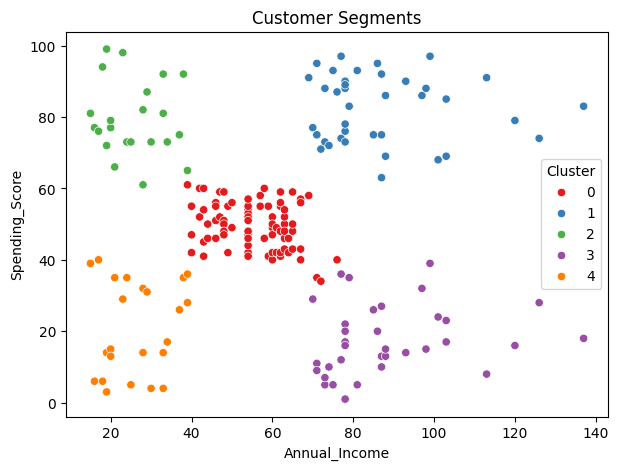

In [14]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

### PCA Visualization

In [15]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df['PCA1'] = components[:,0]
df['PCA2'] = components[:,1]

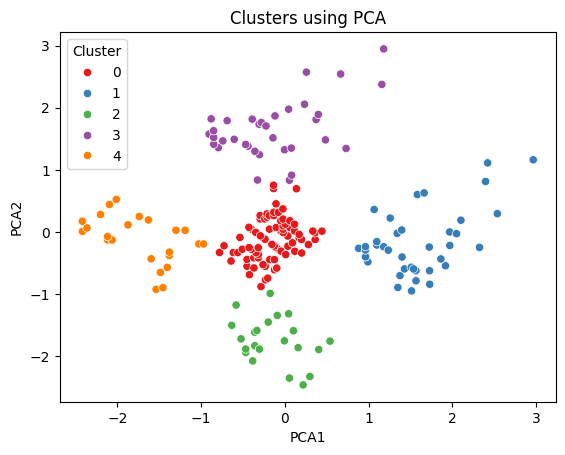

In [16]:
sns.scatterplot(x=df['PCA1'], y=df['PCA2'], hue=df['Cluster'], palette='Set1')
plt.title("Clusters using PCA")
plt.show()

### Cluster Summary

In [17]:
df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean()

,Age,Annual_Income,Spending_Score
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


## Insights

- Customers are not all the same. They naturally fall into different groups based on how much they earn and how much they spend.

- One group includes high income high spending customers, who are the most valuable for the business because they bring in the highest profit.

- Another group has high income but low spending, meaning they have the money but are not spending much. These customers need more personalized marketing to encourage them to buy.

- There are also customers with low income but high spending, who tend to shop frequently and are very responsive to discounts and special offers.

- Some customers fall into the low income and low spending category, who contribute the least to revenue and may need re-engagement or awareness campaigns.

- Finally, there is a balanced group with medium income and medium spending, which represents stable and regular customers who form the core customer base.

## Final Conclusion

- K-Means clustering successfully divided customers into distinct behavioral segments based on spending patterns.

- These segments help businesses understand who spends more, who needs engagement, and who has growth potential.

- PCA visualization confirmed that clusters are clearly separable in reduced dimensions.

- This segmentation enables companies to design targeted marketing strategies, improve customer satisfaction, and maximize revenue.

___________________